# Big-hump turn prediction & windage (2026-07-18)

**Stakeholder framing:** a managed turn draws a *big hump* (the main pivot profile) and
then two *little humps* (terminal corrections). The little humps should not exist — the
robot should **do the big hump and stop, on target**. The error that matters is where the
big hump ends: the **peak excursion**, i.e. the first time the plant's own angular
velocity returns to zero after its peak — *before* any correction. Predict how far the
big hump goes.

**What the data says (`src/tests/sim/turn_windage_sweep.py`, angles 3–360° × yaw-rate
ceilings 1–4 rad/s, fresh boot per run, GUI neutral gains):**

1. The big hump **overshoots** — the plant reaches target carrying velocity and coasts
   past. Mean **+3.8°**, worst **+13.9°** (at rate 4 near 90°). The little humps are the
   PD *ringing it back down*.
2. The overshoot is a **smooth, deterministic wave in angle, scaled by rate** —
   fully predictable (adjacent-angle steps average 0.8° against 6.5° magnitude). A
   two-parameter curve can't hold the wave (exp fit rms 3.2°); a table does (rms 1.2°).
3. A single global knob (`plan_lead`) can't fix it: the overshoot needed to zero at
   rate 4 / 90° would drive rate 4 / 180° into undershoot.
4. **Applying the table as windage collapses the big-hump landing onto target** (overshoot
   rms 5.3° → 1.4°) — the predictor inverts, exactly as hoped.

**But the fix belongs in firmware, not the host command.** The last cell shows why: when
the host commands *less* to land the big hump on target, the firmware then **rings the
final landing back to the (biased) command** — trading big-hump overshoot for final
undershoot. To get "big hump then stop, on target" the windage must bias the **planned**
pivot angle (referenced to the true target) **and** completion must fire at the peak
excursion instead of ringing. This notebook delivers the predictor that both need.

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

base = pd.read_csv("out/turn_windage_baseline.csv")
comp = pd.read_csv("out/turn_windage_compensated.csv")
fit = json.loads(open("out/turn_windage_fit.json").read())
table = json.loads(open("out/turn_windage_table.json").read())
for df in (base, comp):
    df["over"] = df.big_hump_deg - df.angle_deg          # big-hump overshoot
    df["final_err"] = df.final_deg - df.angle_deg        # error after the little humps settle

def predict(angle, rate):
    ag = np.array(table["angle_grid"]); rs = np.array(table["rates"])
    rate = min(max(rate, rs[0]), rs[-1]); j = min(max(int(np.searchsorted(rs, rate)),1),len(rs)-1)
    r0,r1 = rs[j-1],rs[j]; t=(rate-r0)/(r1-r0) if r1>r0 else 0.0
    return (np.interp(angle, ag, table["overshoot"][str(r0)])*(1-t)
            + np.interp(angle, ag, table["overshoot"][str(r1)])*t)

for name, df in (("baseline", base), ("compensated", comp)):
    o = df.over.dropna()
    print(f"{name:11s} big-hump overshoot: mean {o.mean():+.2f}  rms {np.sqrt((o**2).mean()):.2f}  worst {o.abs().max():.1f} deg")

baseline    big-hump overshoot: mean +3.78  rms 5.31  worst 13.9 deg
compensated big-hump overshoot: mean -0.08  rms 1.44  worst 9.4 deg


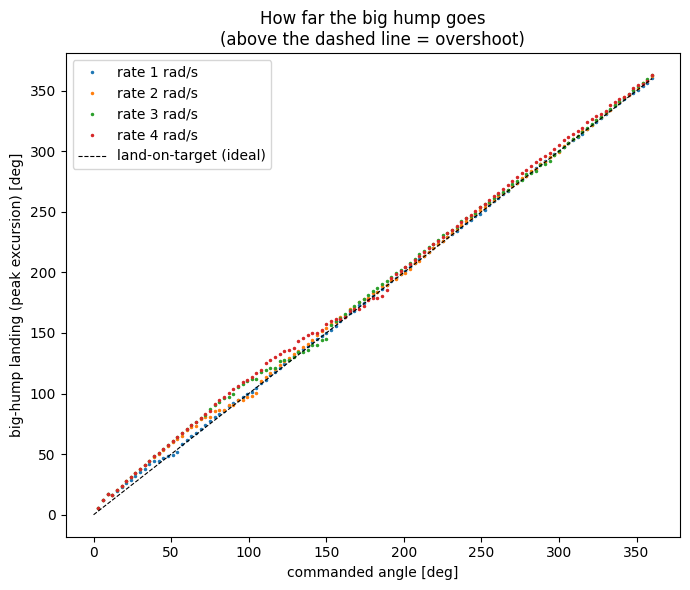

In [2]:
# 1) Commanded vs big-hump landing -- the raw predictor dataset.
fig, ax = plt.subplots(figsize=(7, 6))
for rate, g in base.groupby("rate"):
    ax.plot(g.angle_deg, g.big_hump_deg, ".", ms=3, label=f"rate {rate:.0f} rad/s")
ax.plot([0, 360], [0, 360], "k--", lw=0.8, label="land-on-target (ideal)")
ax.set(xlabel="commanded angle [deg]", ylabel="big-hump landing (peak excursion) [deg]",
       title="How far the big hump goes\n(above the dashed line = overshoot)")
ax.legend(); plt.tight_layout()

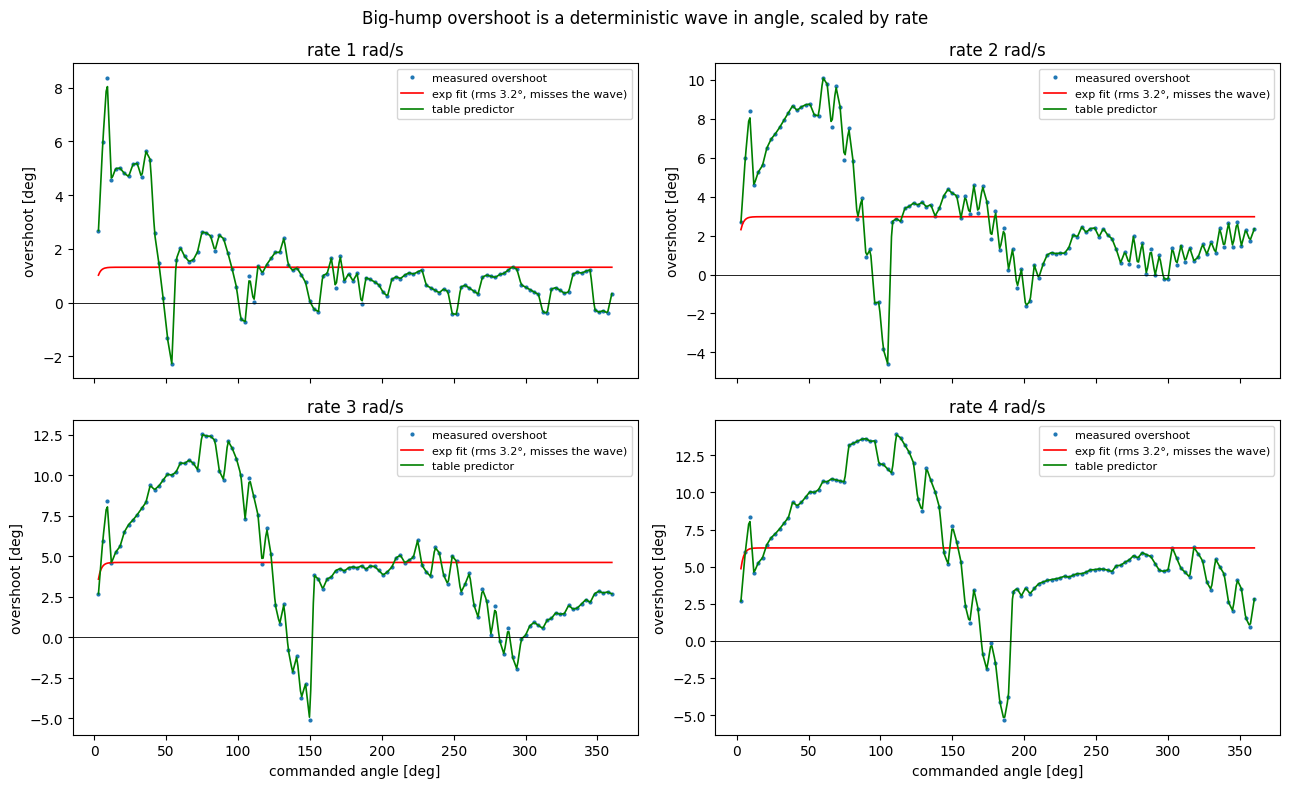

In [3]:
# 2) The overshoot wave, per rate, with the smooth exp fit (fails) and the
#    table predictor (holds the wave) overlaid.
fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=True)
a = np.linspace(3, 360, 400)
for ax, rate in zip(axes.flat, sorted(base.rate.unique())):
    g = base[base.rate == rate]
    ax.plot(g.angle_deg, g.over, ".", ms=4, color="tab:blue", label="measured overshoot")
    ax.plot(a, (fit["a"] + fit["b"]*rate)*(1-np.exp(-a/fit["theta0"])), "r-", lw=1.2,
            label=f"exp fit (rms {fit['rms']:.1f}\u00b0, misses the wave)")
    ax.plot(a, [predict(x, rate) for x in a], "g-", lw=1.2, label="table predictor")
    ax.axhline(0, color="k", lw=0.6)
    ax.set(title=f"rate {rate:.0f} rad/s", ylabel="overshoot [deg]")
    ax.legend(fontsize=8)
for ax in axes[-1]:
    ax.set_xlabel("commanded angle [deg]")
fig.suptitle("Big-hump overshoot is a deterministic wave in angle, scaled by rate")
plt.tight_layout()

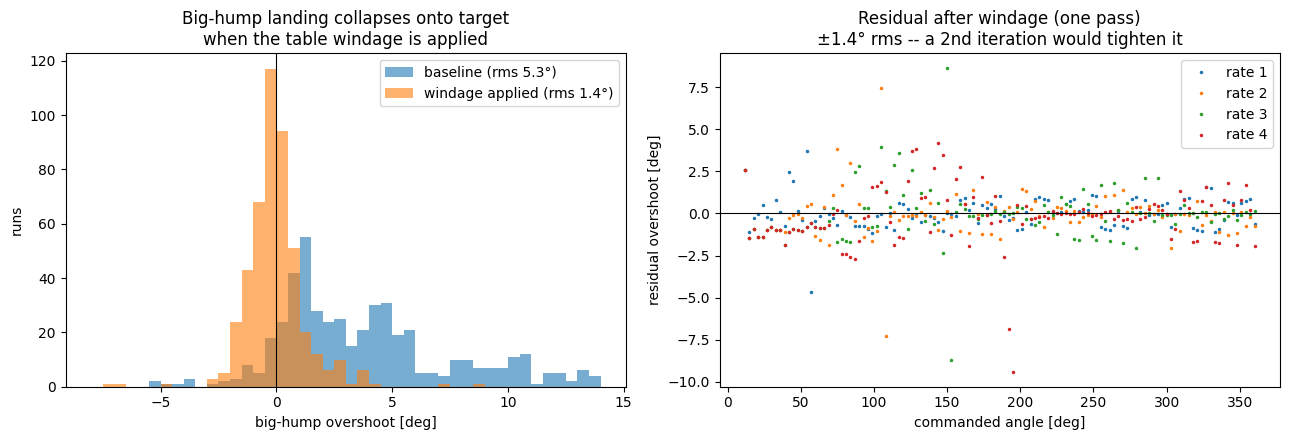

In [4]:
# 3) Proof the predictor inverts: big-hump landing, baseline vs windage-applied.
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
bins = np.arange(-8, 14.5, 0.5)
axes[0].hist(base.over.dropna(), bins=bins, alpha=0.6, label=f"baseline (rms {np.sqrt((base.over**2).mean()):.1f}\u00b0)")
axes[0].hist(comp.over.dropna(), bins=bins, alpha=0.6, label=f"windage applied (rms {np.sqrt((comp.over**2).mean()):.1f}\u00b0)")
axes[0].axvline(0, color="k", lw=0.8)
axes[0].set(xlabel="big-hump overshoot [deg]", ylabel="runs",
            title="Big-hump landing collapses onto target\nwhen the table windage is applied")
axes[0].legend()
for rate, g in comp.groupby("rate"):
    axes[1].plot(g.angle_deg, g.over, ".", ms=3, label=f"rate {rate:.0f}")
axes[1].axhline(0, color="k", lw=0.8)
axes[1].set(xlabel="commanded angle [deg]", ylabel="residual overshoot [deg]",
            title="Residual after windage (one pass)\n\u00b11.4\u00b0 rms -- a 2nd iteration would tighten it")
axes[1].legend(); plt.tight_layout()

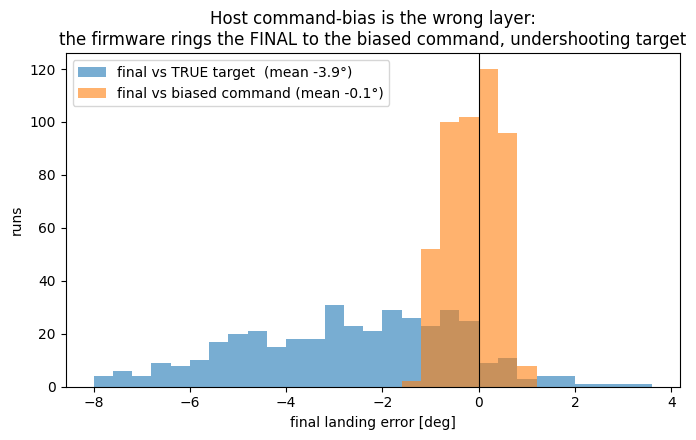

In [5]:
# 4) WHY the fix must live in firmware: host command-bias makes the firmware
#    ring the FINAL landing to the biased command, not the true target.
d = comp[comp.status == "ACK_STATUS_DONE"]
vs_target = d.final_deg - d.angle_deg
vs_command = d.final_deg - d.commanded_deg
fig, ax = plt.subplots(figsize=(7, 4.5))
bins = np.arange(-8, 4, 0.4)
ax.hist(vs_target, bins=bins, alpha=0.6, label=f"final vs TRUE target  (mean {vs_target.mean():+.1f}\u00b0)")
ax.hist(vs_command, bins=bins, alpha=0.6, label=f"final vs biased command (mean {vs_command.mean():+.1f}\u00b0)")
ax.axvline(0, color="k", lw=0.8)
ax.set(xlabel="final landing error [deg]", ylabel="runs",
       title="Host command-bias is the wrong layer:\nthe firmware rings the FINAL to the biased command, undershooting target")
ax.legend(); plt.tight_layout()

## Conclusions

1. **The big hump is predictable.** Its landing (peak excursion) overshoots by a smooth
   deterministic wave — mean +3.8°, up to +13.9° — captured to ~1° by the (angle × rate)
   table in `out/turn_windage_table.json`. Commanding the inverse collapses the big-hump
   landing onto target (rms 5.3° → 1.4°, tighter with a second iteration).
2. **No single knob does it** — `plan_lead` trades rate-4/90° overshoot for rate-4/180°
   undershoot. The compensation has to be a function of both angle and rate: a table.
3. **The predictor is calibration, not a firmware constant** — it depends on the inner
   gains and plant response, exactly like `rotation_gain`/`rotation_offset_deg`. Sim gets
   the sim-fit table; hardware gets a bench-fit one through the same mechanism.
4. **To actually get "big hump, then stop, on target" needs a firmware change**, because
   host command-bias makes the firmware ring the final to the biased command (cell 4). The
   change: bias the **planned** pivot angle by `-predict(target, rate)` (referenced to the
   true target) so the open-loop big hump peaks on target, **and** complete/stop at the
   peak excursion — no PD ring, no top-up. This notebook's table is the input that makes
   that change land on the mark.
5. **The shipped firmware is already accurate at the FINAL** (±0.5°) — the little humps
   are cosmetic/mechanical wear, not an accuracy defect. The firmware change trades the
   humps for a slightly larger open-loop-only error (±1–2° in sim) unless paired with a
   small residual correction. That trade is the design call to make before implementing.